#### Notes
*   Brown Adipose Tissue (BAT) is involved in thermogenesis which burns energy for heat
    *   Located in the neck, upper back and kidneys
    *   High cellular respiration and mitochondria density
    *   Extensive angiogenesis and nervous system integration
*   White Adipose Tissue (WAT) is involved in excess energy storage and insulation
    *   Subcutaneus (under skin) and visceral (around organs)
    *   Triclyceride formation and long-term energy storage
    *   Slow metabolism
    *   Giant fat droplet formation
    *   Endocrine responses

# Start

In [ ]:
req_file = '../OSD-969_OSD-970_req.txt'
env_file = '../OSD-969_OSD-970_env.yml'
repo_url = 'https://github.com/Sybilade/adipose-pcr-spaceflight'
raw_base_url = repo_url.replace("github.com", "raw.githubusercontent.com") + "/main/"
source_url_1 = 'https://osdr.nasa.gov/bio/repo/data/studies/OSD-969'
source_url_2 = 'https://osdr.nasa.gov/bio/repo/data/studies/OSD-970'

In [ ]:
# Download
import os

if repo_url:

    if not os.path.exists(env_file):
        url = raw_base_url + env_file.replace('../', '')
        print(f"Downloading {env_file} from Github...")
        try:
            urllib.request.urlretrieve(url, env_file)
            print(f"Successfully downloaded {env_file} from Github")
        except Exception as e:
            print(f"Could not download {env_file}: {e}")

    if not os.path.exists(req_file):
        url = raw_base_url + req_file.replace('../', '')
        print(f"Downloading {req_file} from Github...")
        try:
            urllib.request.urlretrieve(url, req_file)
            print(f"Successfully downloaded {req_file} from Github")
        except Exception as e:
            print(f"Could not download {req_file}: {e}")
    
    else:
        print("Dependency files downloaded")
    
# Install dependencies
## If using local, prefer mamba or conda
## mamba env update -f osd-968_env.yml
if os.path.exists(req_file):
    print(f"Installing via pip with {req_file}...")
    %pip install -r {req_file}
else:
    print(f"No {req_file} found. Skipping")

Installing via pip with ../OSD-969_OSD-970_req.txt...
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement python==3.11 (from versions: none)
ERROR: No matching distribution found for python==3.11


In [4]:
# Dependencies
import sys
import urllib
import awscli
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

c:\Users\nicks\miniconda3\envs\OSD-969_OSD-970\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data

In [5]:
!aws s3 ls --no-sign-request --recursive --summarize s3://nasa-osdr/OSD-969/version-1/

2026-03-04 03:00:14      15106 OSD-969/version-1/RT-PCR/GLDS-789_RT-PCR_BAT_Ct-values.csv
2026-03-04 03:00:14      29105 OSD-969/version-1/metadata/OSD-969_metadata_OSD-969-ISA.zip

Total Objects: 2
   Total Size: 44211


## BAT

In [6]:
# Import
data_dir = kagglehub.dataset_download('niccosimonetti/adipose-tissue-rna-expression-in-spaceflight/versions/3', 
    force_download=True)
display(os.listdir(data_dir))

display(os.listdir(f'{data_dir}/OSD-969_metadata_OSD-969-ISA'))

df_bat = pd.read_csv(f'{data_dir}/GLDS-789_RT-PCR_BAT_Ct-values.csv')
print(df_bat.shape)
print(list(df_bat.columns))
display(df_bat.head(10))
display(df_bat.describe())

100%|██████████| 39.8k/39.8k [00:00<00:00, 6.71MB/s]

Extracting files...


['GLDS-789_RT-PCR_BAT_Ct-values.csv',
 'GLDS-790_RT-PCR_WAT_Ct-values.csv',
 'OSD-969_metadata_OSD-969-ISA',
 'OSD-970_metadata_OSD-970-ISA']

['a_OSD-969_transcription-profiling_real-time-pcr_Applied Biosystems 7900HT Fast Real-Time PCR System.txt',
 'i_Investigation.txt',
 's_OSD-969.txt']

(89, 18)
['Position', 'Symbol', 'Ground ctl #31', 'Ground ctl #32', 'Ground ctl #34', 'Ground ctl #35', 'Ground ctl #36', 'Ground ctl #37', 'Ground ctl #38', 'Ground ctl #39', 'Flight #21', 'Flight #22', 'Flight #23', 'Flight #25', 'Flight #27', 'Flight #28', 'Flight #29', 'Flight #30']


,Position,Symbol,Ground ctl #31,Ground ctl #32,Ground ctl #34,Ground ctl #35,Ground ctl #36,Ground ctl #37,Ground ctl #38,Ground ctl #39,Flight #21,Flight #22,Flight #23,Flight #25,Flight #27,Flight #28,Flight #29,Flight #30
0,A01,Acacb,22.209913,21.872292,22.132890,20.644073,21.581562,20.700611,21.409292,22.021988,23.689121,23.785892,22.374190,21.241447,21.054394,23.565620,22.047813,21.11307
1,A02,Adig,20.782305,20.559107,20.767958,19.749664,20.511457,19.687819,20.262594,20.522446,21.982733,21.741722,20.895395,20.062555,19.991991,22.344190,20.953098,20.245945
2,A03,Adipoq,21.057589,20.531223,20.794510,19.386633,20.289986,19.441517,19.982288,20.574413,22.772314,22.603144,20.627610,20.341152,20.009310,22.984196,20.996368,20.355923
3,A04,Adrb2,27.407274,27.155195,27.529417,26.979490,25.476152,26.783468,26.382847,26.334550,27.965284,28.317678,25.979382,26.894403,27.238148,28.481596,27.562943,26.953382
4,A05,Agt,29.252787,28.333569,28.445286,26.618855,28.730034,27.723194,28.170507,31.016344,29.693680,31.873653,27.025692,28.333994,28.189327,30.330297,28.707315,28.899708
5,A06,Angpt2,27.605677,27.704245,27.716066,27.302788,27.328384,27.179373,27.134058,27.503881,28.839012,29.065193,27.805626,28.405504,27.485243,28.127703,27.854866,27.805363
6,A07,Axin1,26.500870,26.171360,26.454142,25.382263,26.504850,25.597956,26.116798,26.499280,28.161112,28.711002,26.874600,26.169535,25.957626,27.844818,26.638838,25.795353
7,A08,Bmp2,31.139977,31.291712,30.960377,30.088373,31.647860,30.843122,30.748285,31.303470,32.795025,32.831562,31.527107,31.291151,31.090235,32.297150,31.777035,30.96084
8,A09,Bmp4,30.310894,29.687150,30.073069,29.429335,30.106424,29.270897,30.081831,29.397484,30.578342,31.375265,28.439530,29.672747,29.770485,31.857346,29.939636,29.558525
9,A10,Bmp7,30.569036,30.854998,30.956758,29.442316,30.609806,30.550365,30.588758,29.911516,31.519619,31.929829,29.999490,30.534668,30.522905,31.267622,30.754965,30.527266


,Ground ctl #31,Ground ctl #32,Ground ctl #34,Ground ctl #35,Ground ctl #36,Ground ctl #37,Ground ctl #38,Ground ctl #39,Flight #21,Flight #22,Flight #23,Flight #25,Flight #27,Flight #28,Flight #29
count,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,25.363410,25.199645,25.524418,24.423089,25.297404,24.726833,25.067281,25.887842,26.791042,27.221774,25.442175,25.159151,24.886112,26.586768,25.527126
std,3.661233,3.676519,3.785596,3.692053,3.901720,3.778082,3.654767,3.987059,3.895565,4.056901,3.660640,3.854113,3.862877,3.553193,3.696133
min,16.237375,15.735806,16.033276,14.813653,15.364354,14.727357,15.517365,15.829611,16.981443,16.909185,16.140066,15.340072,15.106457,17.378235,15.822698
25%,23.484392,23.121601,23.461891,22.521673,23.445013,22.757282,23.515413,23.542418,24.741600,24.742220,23.820257,22.729479,22.874190,24.691502,23.821665
50%,25.490545,25.362957,25.782160,24.739030,25.500374,24.883785,25.374788,26.119642,26.793438,27.484566,25.534418,25.312588,24.977596,26.821226,25.817354
75%,27.477400,27.143187,27.347635,26.341978,27.154396,26.892725,26.846117,28.783052,29.320250,29.356949,27.269793,27.497795,26.808683,28.464417,27.377110
max,33.383392,34.703720,36.888840,35.719624,37.546680,34.137417,32.564870,33.909615,37.370340,39.189793,33.816235,33.827183,34.137917,33.503560,32.889320


### metadata

In [7]:
study_metadata = pd.read_csv(f'{data_dir}/OSD-969_metadata_OSD-969-ISA/s_OSD-969.txt', sep='\t')
investigation_metadata = pd.read_csv(f'{data_dir}/OSD-969_metadata_OSD-969-ISA/i_Investigation.txt', sep='\t')
assay_metadata = pd.read_csv(f'{data_dir}/OSD-969_metadata_OSD-969-ISA/a_OSD-969_transcription-profiling_real-time-pcr_Applied Biosystems 7900HT Fast Real-Time PCR System.txt', sep='\t')

display(study_metadata.head())
print(investigation_metadata.head())
display(assay_metadata.head())

,Source Name,Sample Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Animal Source],Characteristics[Genotype],...,Term Accession Number.8,Parameter Value[Carcass Preservation Method],Protocol REF.1,Parameter Value[Sample Preservation Method],Term Source REF.9,Term Accession Number.9,Parameter Value[Sample Storage Temperature],Unit.2,Term Source REF.10,Term Accession Number.10
0,RR1_GC_M31,Ground ctl #31,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
1,RR1_GC_M32,Ground ctl #32,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
2,RR1_GC_M34,Ground ctl #34,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
3,RR1_GC_M35,Ground ctl #35,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
4,RR1_GC_M36,Ground ctl #36,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027


                                                                                                                                                               ONTOLOGY SOURCE REFERENCE
Term Source Name        EFO                                        NCIT nan                                     OBI                                        CRO                      MESH
Term Source File        http://data.bioontology.org/ontologies/EFO nan  http://purl.obolibrary.org/obo/ncit.owl http://data.bioontology.org/ontologies/OBI nan                       NaN
Term Source Version     132                                        nan  18.10e                                  29                                         nan                       NaN
Term Source Description Experimental Factor Ontology               nan  NCI Thesaurus OBO Edition               Ontology for Biomedical Investigations     nan                       NaN
INVESTIGATION           nan                                        nan  nan

,Sample Name,Protocol REF,Extract Name,Parameter Value[QA Instrument],Parameter Value[QA Score],Unit,Term Source REF,Term Accession Number,Protocol REF.1,Protocol REF.2,Parameter Value[Assay Panel],Assay Name,Raw Data File
0,Ground ctl #31,Nucleic Acid Extraction,Ground ctl #31,Agilent Bioanalyzer,7.42 +/- 0.46,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-789_RT-PCR_BAT_Ct-values.csv
1,Ground ctl #32,Nucleic Acid Extraction,Ground ctl #32,Agilent Bioanalyzer,7.42 +/- 0.46,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-789_RT-PCR_BAT_Ct-values.csv
2,Ground ctl #34,Nucleic Acid Extraction,Ground ctl #34,Agilent Bioanalyzer,7.42 +/- 0.46,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-789_RT-PCR_BAT_Ct-values.csv
3,Ground ctl #35,Nucleic Acid Extraction,Ground ctl #35,Agilent Bioanalyzer,7.42 +/- 0.46,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-789_RT-PCR_BAT_Ct-values.csv
4,Ground ctl #36,Nucleic Acid Extraction,Ground ctl #36,Agilent Bioanalyzer,7.42 +/- 0.46,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-789_RT-PCR_BAT_Ct-values.csv


## WAT

In [8]:
display(os.listdir(f'{data_dir}/OSD-970_metadata_OSD-970-ISA'))

['a_OSD-970_transcription-profiling_real-time-pcr_Applied Biosystems 7900HT Fast Real-Time PCR System.txt',
 'i_Investigation.txt',
 's_OSD-970.txt']

In [9]:
# Peek at the first 5 lines of the file
# Shows that NASA actually uploaded an excel file (PK), but added the .csv extension :/
with open(f'{data_dir}/GLDS-790_RT-PCR_WAT_Ct-values.csv', 'rb') as f:
    for i in range(5):
        print(f.readline())

b'PK\x03\x04\x14\x00\x06\x00\x08\x00\x00\x00!\x00b\xee\x9dh^\x01\x00\x00\x90\x04\x00\x00\x13\x00\x08\x02[Content_Types].xml \xa2\x04\x02(\xa0\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [10]:
df_wat = pd.read_excel(f'{data_dir}/GLDS-790_RT-PCR_WAT_Ct-values.csv')
print(df_wat.shape)
print(list(df_wat.columns))
display(df_wat.head(10))
display(df_wat.describe())

(89, 18)
['Position', 'Symbol', 'Ground ctl #33', 'Ground ctl #34', 'Ground ctl #35', 'Ground ctl #36', 'Ground ctl #37', 'Ground ctl #38', 'Ground ctl #39', 'Ground ctl #40', 'Flight #23', 'Flight #24', 'Flight #25', 'Flight #26', 'Flight #27', 'Flight #28', 'Flight #29', 'Flight #30']


,Position,Symbol,Ground ctl #33,Ground ctl #34,Ground ctl #35,Ground ctl #36,Ground ctl #37,Ground ctl #38,Ground ctl #39,Ground ctl #40,Flight #23,Flight #24,Flight #25,Flight #26,Flight #27,Flight #28,Flight #29,Flight #30
0,A01,Acacb,25.914785,26.838072,27.022198,29.840216,26.325565,27.718788,28.339878,27.269306,27.705471,26.489044,28.971382,26.727058,27.227451,25.8095,25.386650,29.976095
1,A02,Adig,22.865719,24.115864,23.752766,26.081951,22.764000,24.129812,24.770779,23.707129,25.425806,23.931131,28.141912,25.371250,24.647284,24.458633,23.914782,27.632442
2,A03,Adipoq,20.953014,21.618462,21.117342,26.129042,20.511137,21.904360,22.524416,20.959171,23.516120,22.417099,28.552092,23.971262,22.716240,22.869368,21.990948,27.609360
3,A04,Adrb2,28.695105,29.310120,29.982672,31.99825,29.196722,29.785234,29.700070,29.126036,30.637540,30.035318,30.000124,30.807968,29.847303,30.686375,29.722584,32.163265
4,A05,Agt,25.818481,23.996582,25.290869,28.841074,24.488356,26.390545,26.729185,23.914766,27.351484,27.053524,30.203392,27.675344,25.367798,26.792315,26.072393,30.634449
5,A06,Angpt2,25.152180,26.497404,27.248035,27.629505,26.117450,27.131006,27.310650,26.83768,29.475332,28.558802,29.322596,29.668337,28.222378,27.933973,28.202910,28.663687
6,A07,Axin1,27.847132,26.606752,29.419722,31.339117,28.011848,29.120530,29.840485,28.207525,29.386095,29.415000,30.664736,30.737148,29.660364,29.701576,28.856842,32.752357
7,A08,Bmp2,29.277311,27.123877,31.064312,31.43228,29.850992,30.086828,32.125893,30.857868,30.214895,29.969160,30.322884,30.508902,30.632534,31.528507,29.973333,32.081932
8,A09,Bmp4,28.601954,28.304806,30.876627,31.303175,27.770893,29.566925,29.894388,28.697695,30.610430,29.593136,31.058947,33.859440,31.240410,30.726795,29.473595,33.256836
9,A10,Bmp7,29.325687,29.318987,31.211855,31.605423,30.529337,31.400742,31.458190,30.556301,30.424139,29.437115,30.179983,29.710535,31.180270,31.659319,29.955880,31.731186


,Ground ctl #33,Ground ctl #34,Ground ctl #35,Ground ctl #37,Ground ctl #38,Ground ctl #39,Flight #23,Flight #24,Flight #25,Flight #26,Flight #27,Flight #29,Flight #30
count,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000,89.000000
mean,26.684882,26.768981,27.981945,26.903002,27.909089,28.720270,28.705702,27.842241,29.640944,29.006551,28.462367,27.422367,30.905832
std,2.756341,3.155811,3.446325,3.330567,3.065235,3.099997,2.403004,2.638937,1.849334,3.160866,3.169802,2.672232,2.834712
min,17.412338,18.240866,17.768877,17.086060,18.529236,19.217780,20.261852,18.786137,23.130562,19.671139,19.176615,18.545795,21.367022
25%,25.998407,25.718111,26.744864,25.659832,26.872805,27.662428,28.441698,27.301584,29.179700,27.939262,27.227451,26.902754,29.889923
50%,27.118200,26.621178,28.308973,26.903772,28.015583,28.927753,29.340097,28.654976,30.158266,29.425655,28.771442,28.202910,31.573786
75%,28.601954,28.404781,30.104336,28.912070,29.726606,30.515419,30.086859,29.437115,30.771990,30.623507,30.419750,28.927214,32.522167
max,30.594590,35.490612,34.316610,33.671500,33.623580,34.273193,31.913824,31.965452,32.821860,36.149660,38.000660,31.944231,38.017370


In [11]:
# Save formatted csv
df_wat.to_csv(
    '../data/processed/GLDS-790_RT-PCR_WAT_Ct-values_formatted.csv',
    index=False,
    encoding='utf-8'
)

# working
pd.read_csv('../data/processed/GLDS-790_RT-PCR_WAT_Ct-values_formatted.csv')

,Position,Symbol,Ground ctl #33,Ground ctl #34,Ground ctl #35,Ground ctl #36,Ground ctl #37,Ground ctl #38,Ground ctl #39,Ground ctl #40,Flight #23,Flight #24,Flight #25,Flight #26,Flight #27,Flight #28,Flight #29,Flight #30
0,A01,Acacb,25.914785,26.838072,27.022198,29.840216,26.325565,27.718788,28.339878,27.269306,27.705471,26.489044,28.971382,26.727058,27.227451,25.8095,25.386650,29.976095
1,A02,Adig,22.865719,24.115864,23.752766,26.081951,22.764000,24.129812,24.770779,23.707129,25.425806,23.931131,28.141912,25.371250,24.647284,24.458633,23.914782,27.632442
2,A03,Adipoq,20.953014,21.618462,21.117342,26.129042,20.511137,21.904360,22.524416,20.959171,23.516120,22.417099,28.552092,23.971262,22.716240,22.869368,21.990948,27.609360
3,A04,Adrb2,28.695105,29.310120,29.982672,31.99825,29.196722,29.785234,29.700070,29.126036,30.637540,30.035318,30.000124,30.807968,29.847303,30.686375,29.722584,32.163265
4,A05,Agt,25.818481,23.996582,25.290869,28.841074,24.488356,26.390545,26.729185,23.914766,27.351484,27.053524,30.203392,27.675344,25.367798,26.792315,26.072393,30.634449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,H01,Actb,21.443330,20.342490,21.740194,25.821522,21.242245,22.516176,23.304610,21.143974,24.552616,23.251175,27.697609,24.158901,23.204994,22.804293,22.870890,27.129555
85,H02,B2m,19.584970,19.821812,20.120472,24.497162,19.397017,20.806860,21.494170,19.56818,22.531565,20.800358,26.361645,21.736881,21.737110,21.178299,21.154066,25.388348
86,H03,Gapdh,20.648863,20.774061,21.914192,25.621252,20.936079,22.214450,23.424839,22.108799,23.031256,21.896496,24.295650,22.486560,23.227130,21.974867,21.502209,25.467370
87,H04,Gusb,27.045542,26.033728,27.422667,30.148447,26.678720,27.754414,28.614157,27.138361,29.434656,28.474377,31.051378,29.761122,28.638416,28.541494,27.976278,30.750070


### metadata

In [12]:
study_metadata = pd.read_csv(f'{data_dir}/OSD-970_metadata_OSD-970-ISA/s_OSD-970.txt', sep='\t')
investigation_metadata = pd.read_csv(f'{data_dir}/OSD-970_metadata_OSD-970-ISA/i_Investigation.txt', sep='\t')
assay_metadata = pd.read_csv(f'{data_dir}/OSD-970_metadata_OSD-970-ISA/a_OSD-970_transcription-profiling_real-time-pcr_Applied Biosystems 7900HT Fast Real-Time PCR System.txt', sep='\t')

display(study_metadata.head())
print(investigation_metadata.head())
display(assay_metadata.head())

,Source Name,Sample Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Animal Source],Characteristics[Genotype],...,Term Accession Number.8,Parameter Value[Carcass Preservation Method],Protocol REF.1,Parameter Value[Sample Preservation Method],Term Source REF.9,Term Accession Number.9,Parameter Value[Sample Storage Temperature],Unit.2,Term Source REF.10,Term Accession Number.10
0,RR1_GC_M33,Ground ctl #33,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
1,RR1_GC_M34,Ground ctl #34,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
2,RR1_GC_M35,Ground ctl #35,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
3,RR1_GC_M36,Ground ctl #36,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027
4,RR1_GC_M37,Ground ctl #37,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Jackson Laboratory,Wild Type,...,http://purl.bioontology.org/ontology/RXNORM/11...,Mini Cold Bag to -80C freezer,sample collection,RNALater,NCIT,http://purl.obolibrary.org/obo/NCIT_C63348,-80,degree Celsius,UO,http://purl.obolibrary.org/obo/UO_0000027


                                                                                                                                                               ONTOLOGY SOURCE REFERENCE
Term Source Name        EFO                                        NCIT nan                                     OBI                                        CRO                      MESH
Term Source File        http://data.bioontology.org/ontologies/EFO nan  http://purl.obolibrary.org/obo/ncit.owl http://data.bioontology.org/ontologies/OBI nan                       NaN
Term Source Version     132                                        nan  18.10e                                  29                                         nan                       NaN
Term Source Description Experimental Factor Ontology               nan  NCI Thesaurus OBO Edition               Ontology for Biomedical Investigations     nan                       NaN
INVESTIGATION           nan                                        nan  nan

,Sample Name,Protocol REF,Extract Name,Parameter Value[QA Instrument],Parameter Value[QA Score],Unit,Term Source REF,Term Accession Number,Protocol REF.1,Protocol REF.2,Parameter Value[Assay Panel],Assay Name,Raw Data File
0,Ground ctl #33,Nucleic Acid Extraction,Ground ctl #31,Agilent Bioanalyzer,equals to or greater than 5,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-790_RT-PCR_WAT_Ct-values.csv
1,Ground ctl #34,Nucleic Acid Extraction,Ground ctl #32,Agilent Bioanalyzer,equals to or greater than 5,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-790_RT-PCR_WAT_Ct-values.csv
2,Ground ctl #35,Nucleic Acid Extraction,Ground ctl #34,Agilent Bioanalyzer,equals to or greater than 5,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-790_RT-PCR_WAT_Ct-values.csv
3,Ground ctl #36,Nucleic Acid Extraction,Ground ctl #35,Agilent Bioanalyzer,equals to or greater than 5,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-790_RT-PCR_WAT_Ct-values.csv
4,Ground ctl #37,Nucleic Acid Extraction,Ground ctl #36,Agilent Bioanalyzer,equals to or greater than 5,RNA Integrity Number,NCIT,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus...,Reverse Transcribed Pcr,Data Collection,Mouse Adipogenesis RT^2 Profiler PCR Array (Qi...,RT-PCR,GLDS-790_RT-PCR_WAT_Ct-values.csv


# Clean

In [13]:
print((df_bat == 'Undetermined').sum())
print()
print((df_wat == 'Undetermined').sum())

df_bat = df_bat.replace('Undetermined', float('nan'))
df_wat = df_wat.replace('Undetermined', float('nan'))

Position          0
Symbol            0
Ground ctl #31    0
Ground ctl #32    0
Ground ctl #34    0
Ground ctl #35    0
Ground ctl #36    0
Ground ctl #37    0
Ground ctl #38    0
Ground ctl #39    0
Flight #21        0
Flight #22        0
Flight #23        0
Flight #25        0
Flight #27        0
Flight #28        0
Flight #29        0
Flight #30        1
dtype: int64

Position          0
Symbol            0
Ground ctl #33    0
Ground ctl #34    0
Ground ctl #35    0
Ground ctl #36    1
Ground ctl #37    0
Ground ctl #38    0
Ground ctl #39    0
Ground ctl #40    1
Flight #23        0
Flight #24        0
Flight #25        0
Flight #26        0
Flight #27        0
Flight #28        1
Flight #29        0
Flight #30        0
dtype: int64


# Figures
- CT values = Cycle threshold
    - How many cycles of PCR it takes for the gene's flourescence signal can become detactable
    - Mouse Adipogenesis RT^2 Profiler PCR Array = 84 gene panel related to fat cell biology + controls
    - low CT 15-20: highly expressed
    - high CT 30-40: low expression
    - greater may be undetectable

## heatmap

Text(0.5, 1.0, 'BAT RT-PCR CT values')

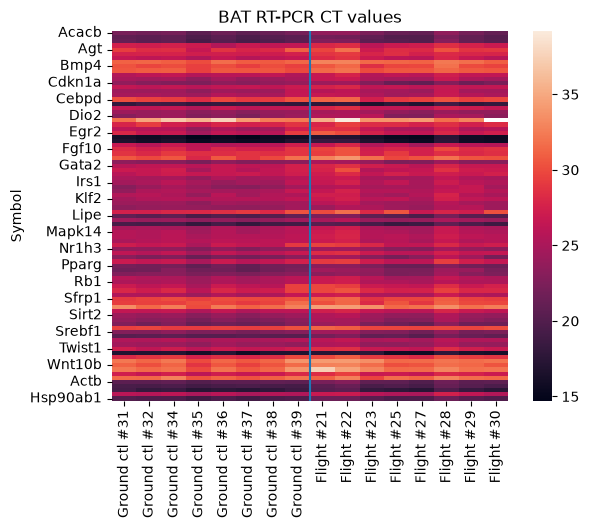

In [14]:
# BAT
## remove position coloumn
df_bat_heat = df_bat.set_index('Symbol').drop(columns='Position')

# separate columns
gc_cols = [c for c in df_bat_heat.columns if 'ctl' in c]
fl_cols = [c for c in df_bat_heat.columns if 'Flight' in c]
df_bat_heat = df_bat_heat[gc_cols + fl_cols]

df_bat_heat = df_bat_heat.astype(float)

sns.heatmap(df_bat_heat)

plt.axvline(x=len(gc_cols))
plt.title('BAT RT-PCR CT values')

Text(0.5, 1.0, 'wat RT-PCR CT values')

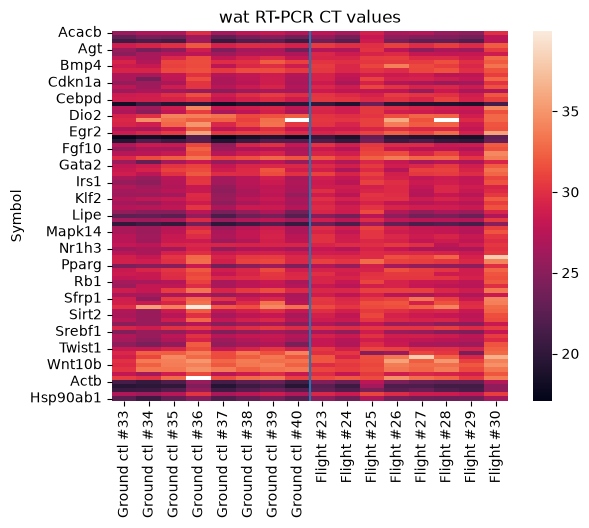

In [15]:
# wat
## remove position coloumn
df_wat_heat = df_wat.set_index('Symbol').drop(columns='Position')

# separate columns
gc_cols = [c for c in df_wat_heat.columns if 'ctl' in c]
fl_cols = [c for c in df_wat_heat.columns if 'Flight' in c]
df_wat_heat = df_wat_heat[gc_cols + fl_cols]

df_wat_heat = df_wat_heat.astype(float)

sns.heatmap(df_wat_heat)

plt.axvline(x=len(gc_cols))
plt.title('wat RT-PCR CT values')

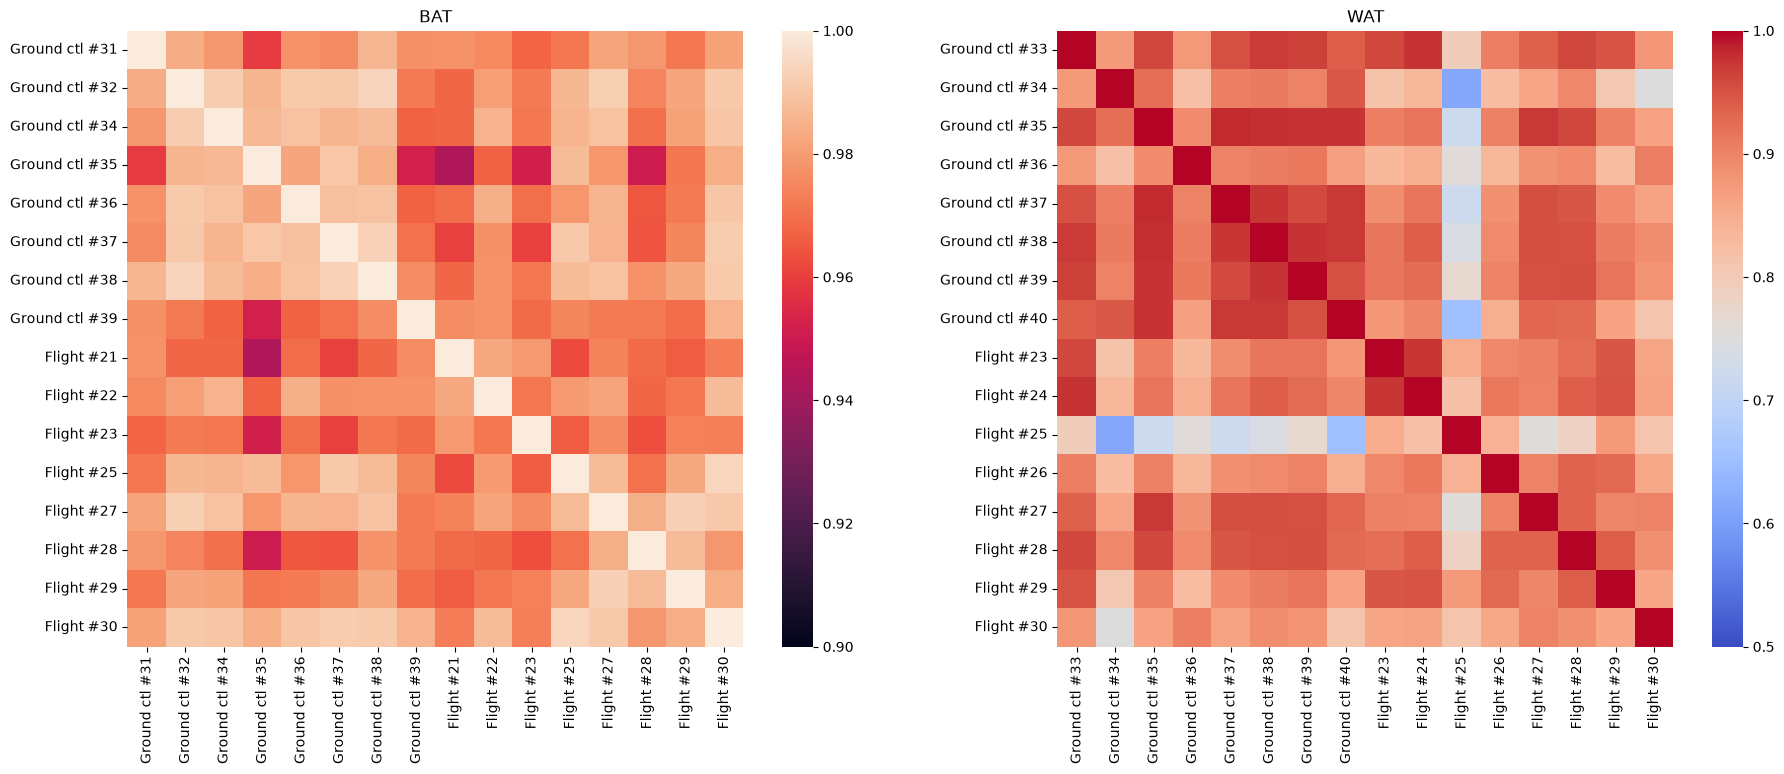

In [16]:
df_bat_corr = df_bat.set_index('Symbol').drop(columns='Position')
bat_corr = df_bat_corr.corr()
gc_bat_cols = [c for c in df_bat_corr.columns if 'ctl' in c]
fl_bat_cols = [c for c in df_bat_corr.columns if 'Flight' in c]
df_bat_corr = df_bat_corr[gc_bat_cols + fl_bat_cols]
bat_corr = df_bat_corr.corr()

df_wat_corr = df_wat.set_index('Symbol').drop(columns='Position')
gc_wat_cols = [c for c in df_wat_corr.columns if 'ctl' in c]
fl_wat_cols = [c for c in df_wat_corr.columns if 'Flight' in c]
df_wat_corr = df_wat_corr[gc_wat_cols + fl_wat_cols]
wat_corr = df_wat_corr.corr()

fig, axes = plt.subplots(1, 2, figsize= (22,8))
sns.heatmap(bat_corr, vmin=0.9, vmax=1.0, square=True, ax=axes[0])
axes[0].set_title('BAT')
sns.heatmap(wat_corr, vmin=0.5, vmax=1.0, square=True, cmap='coolwarm', ax=axes[1])
axes[1].set_title('WAT')
plt.subplots_adjust(wspace=0.2)

## violin

Text(0.5, 1.0, 'WAT')

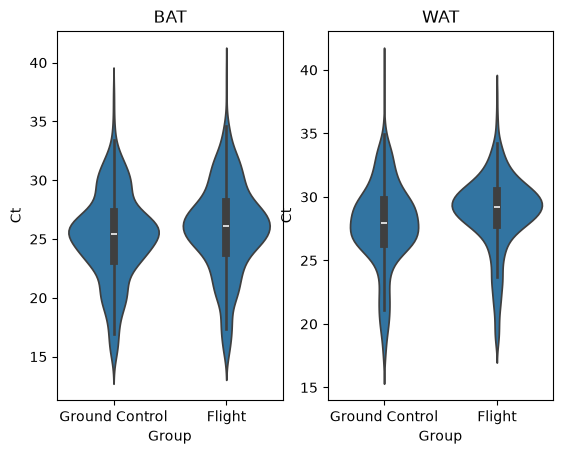

In [17]:
# bat
df_bat_violin = df_bat.set_index('Symbol').drop(columns='Position').reset_index()

# one row per measurement
df_bat_violin = df_bat_violin.melt(id_vars='Symbol', var_name='Sample', value_name='Ct')
df_bat_violin['Group'] = df_bat_violin['Sample'].apply(lambda x: 'Ground Control' if 'ctl' in x else 'Flight')

#wat
df_wat_violin = df_wat.set_index('Symbol').drop(columns='Position').reset_index()

df_wat_violin = df_wat_violin.melt(id_vars='Symbol', var_name='Sample', value_name='Ct')
df_wat_violin['Group'] = df_wat_violin['Sample'].apply(lambda x: 'Ground Control' if 'ctl' in x else 'Flight')

fig, axes = plt.subplots(1, 2)


sns.violinplot(data=df_bat_violin, x='Group', y='Ct', ax=axes[0])
axes[0].set_title('BAT')
axes[0].invert_yaxis()

sns.violinplot(data=df_wat_violin, x='Group', y='Ct', ax=axes[1])
axes[1].set_title('WAT')

## distribution

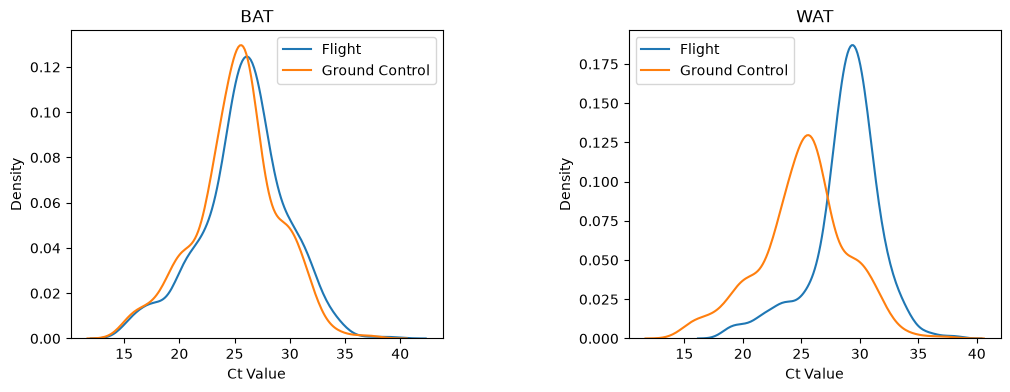

In [18]:
fl_bat_vals = df_bat[fl_bat_cols].values.flatten().astype(float)
gc_bat_vals = df_bat[gc_bat_cols].values.flatten().astype(float)

fl_wat_vals = df_wat[fl_wat_cols].values.flatten()
gc_wat_vals = df_wat[gc_wat_cols].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.kdeplot(fl_bat_vals, label='Flight', ax=axes[0])
sns.kdeplot(gc_bat_vals, label='Ground Control', ax=axes[0])
axes[0].set_title('BAT')
sns.kdeplot(fl_wat_vals, label='Flight', ax=axes[1])
sns.kdeplot(gc_bat_vals, label='Ground Control', ax=axes[1])
axes[1].set_title('WAT')
axes[0].set_xlabel('Ct Value')
axes[1].set_xlabel('Ct Value')
axes[0].legend()
axes[1].legend()
plt.subplots_adjust(wspace=.5)

Ct shift for WAT from gc to flight is 25 -> 30 for peak
- 1 ct shift = 2^x difference in gene expression
- 5 ct shift = 2^5 = x32 more gene expression

## scatter

Text(0, 0.5, 'WAT Log2FC')

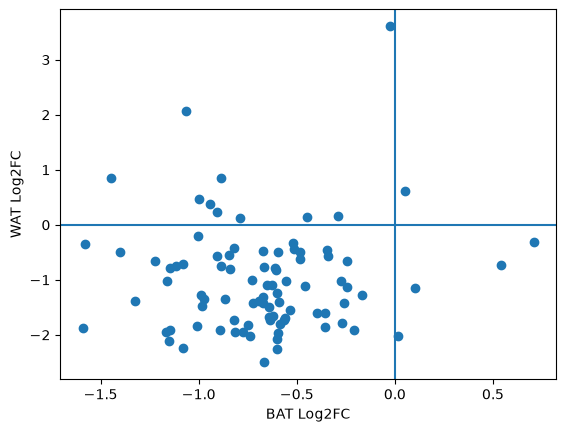

In [31]:
num_bat_cols = df_bat.columns.drop(['Position', 'Symbol'])
df_bat[num_bat_cols] = df_bat[num_bat_cols].astype(float)

num_wat_cols = df_wat.columns.drop(['Position', 'Symbol'])
df_wat[num_wat_cols] = df_wat[num_wat_cols].astype(float)

gc_bat_mean = df_bat[gc_bat_cols].mean(axis=1)
fl_bat_mean = df_bat[fl_bat_cols].mean(axis=1)
fl_wat_mean = df_wat[fl_wat_cols].mean(axis=1)
gc_wat_mean = df_wat[gc_wat_cols].mean(axis=1)

bat_log2fc = gc_bat_mean - fl_bat_mean
wat_log2fc = gc_wat_mean - fl_wat_mean

df_log2fc = pd.DataFrame({'BAT Log2FC':bat_log2fc, 'WAT Log2FC':wat_log2fc})

plt.scatter(df_log2fc['BAT Log2FC'], df_log2fc['WAT Log2FC'])
plt.axhline(0)
plt.axvline(0)
plt.xlabel('BAT Log2FC')
plt.ylabel('WAT Log2FC')

quandrant 3 represents downregulated gene expression (higher Ct mean from flight RT-PCR results) in both BAT and WAT during flight